# Measuring the Redshift of a JWST/NIRSpec Spectrum

This tutorial fits the redshift of a real JWST/NIRSpec spectrum with BESTA's `RedshiftFullFitModule` using a full-spectrum likelihood and a `maxlike` optimizer.

## What this tutorial covers

- Loading a one-dimensional NIRSpec spectrum from a FITS file
- Masking unusable pixels and exporting the spectrum to the text format expected by the pipeline
- Configuring and running a BESTA redshift fit
- Reading the maximum-likelihood solution and comparing it to the literature redshift
- Plotting the best-fit and residuals for a quick quality check

## Before you run it

- Use the project Python environment with `besta`, `astropy`, and `matplotlib` available
- Expect the `maxlike` step to emit optimizer logs while the pipeline runs
- The notebook writes its intermediate files next to the tutorial data so it can be launched either from the repository root or from the tutorial directory

The workflow is intentionally explicit so you can reuse each intermediate product in your own spectra-fitting notebooks.

In [1]:
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt
from astropy import units as u
from astropy.io import fits

## 1. Inspect the Input Spectrum

The bundled FITS file contains the extracted one-dimensional spectrum, its uncertainty, and a sky estimate. This first pass is only for inspection: we plot the raw arrays and build a simple binary mask that downweights invalid pixels before fitting.

Pixels with non-finite fluxes or non-positive uncertainties are treated as unusable. The notebook keeps them in the exported file but assigns them a zero weight through a separate mask file.

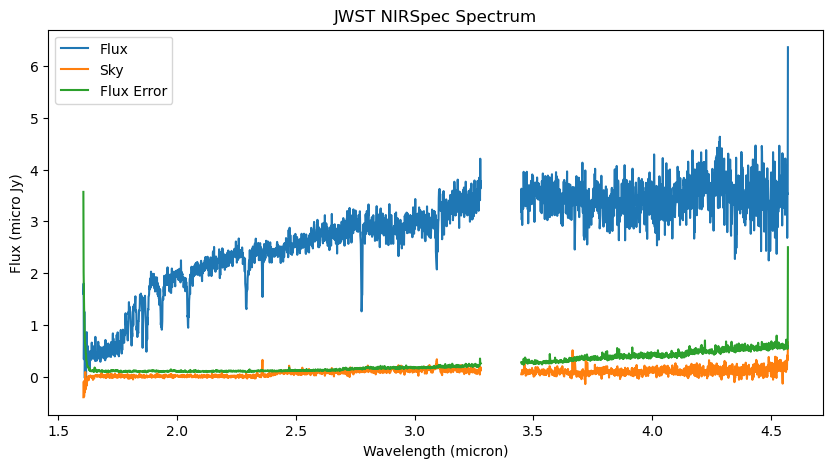

In [2]:
tutorial_dir = Path.cwd()
if not (tutorial_dir / "valentino-cosmos04-v4_g235m-f170lp_3567_54459.spec.fits").exists():
    tutorial_dir = Path.cwd() / "tutorials" / "fit_redshift"

spectrum_path = tutorial_dir / "valentino-cosmos04-v4_g235m-f170lp_3567_54459.spec.fits"
if not spectrum_path.exists():
    raise FileNotFoundError(f"Could not find the tutorial spectrum at {spectrum_path}")

with fits.open(spectrum_path) as hdul:

    wl = hdul["SPEC1D"].data["wave"] * u.micron
    flux = hdul["SPEC1D"].data["flux"] * u.uJy
    flux_error = hdul["SPEC1D"].data["err"] * u.uJy
    sky = hdul["SPEC1D"].data["sky"]

plt.figure(figsize=(10, 5))
plt.plot(wl, flux, label="Flux")
plt.plot(wl, sky, label="Sky")
plt.plot(wl, flux_error, label="Flux Error")
plt.xlabel("Wavelength (micron)")
plt.ylabel("Flux (micro Jy)")
plt.title("JWST NIRSpec Spectrum")
plt.legend()
plt.show()

bad_pixels = ~np.isfinite(flux) | ~np.isfinite(flux_error) | (flux_error <= 0)
weights = 1 - bad_pixels.astype(float)
flux_error[bad_pixels] = 1e10 * u.uJy


## 2. Convert to the Flux Units Used by BESTA

The pipeline expects wavelength in Angstrom and flux density in $\mathrm{erg\ s^{-1}\ cm^{-2}\ \AA^{-1}}$. This cell converts the original micro-Jansky spectrum into those units, saves the spectrum to disk, and writes the weight vector to a separate text file.

Saving these intermediate files is useful beyond the tutorial: they become a reproducible hand-off between data reduction and model fitting.

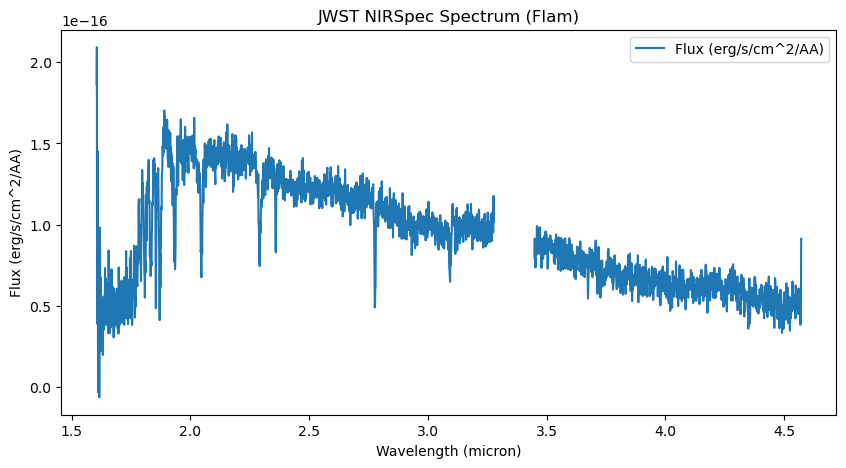

In [3]:
# Prepare the data for fitting

flux_flam = (flux * (3e8 * u.km / u.s) / wl**2).to(u.erg / (u.s * u.cm**2 * u.AA))

flux_error_flam = (flux_error * (3e8 * u.km / u.s) / wl**2).to(u.erg / (u.s * u.cm**2 * u.AA))

spectrum_txt_path = tutorial_dir / "jwst_spectrum.txt"
weights_txt_path = tutorial_dir / "jwst_spectrum_weights.txt"

plt.figure(figsize=(10, 5))
plt.plot(wl, flux_flam, label="Flux (erg/s/cm^2/AA)")

plt.xlabel("Wavelength (micron)")
plt.ylabel("Flux (erg/s/cm^2/AA)")
plt.title("JWST NIRSpec Spectrum (Flam)")
plt.legend()

np.savetxt(
    spectrum_txt_path,
    np.column_stack((
        wl.to_value(u.AA),
        flux_flam.to_value(u.erg / (u.s * u.cm**2 * u.AA)),
        flux_error_flam.to_value(u.erg / (u.s * u.cm**2 * u.AA)),
    )),
    header="Wavelength (micron) Flux (erg/s/cm^2/AA) Flux_Error (erg/s/cm^2/AA)",
)

np.savetxt(
    weights_txt_path,
    weights,
    header="Weights for fitting (1=good pixel, 0=bad pixel)",
)

In [4]:
from besta import MainPipeline
from besta.pipeline_modules.redshift_fit_full_sampling import RedshiftFullFitModule

## 3. Configure and Run the Redshift Fit

The next cells import the BESTA pipeline objects and define a minimal configuration for a maximum-likelihood redshift fit. In this example the observed spectrum stays in the observed frame, while the module shifts the model internally over the redshift range defined by `z_min` and `z_max`.

The small `values.ini` file only exposes a few nuisance parameters so the tutorial stays fast and the optimizer has a valid search region.

In [6]:
# ── Configuration ─────────────────────────────────────────────────────────────

output_root = tutorial_dir / "results.jwst_redshift_maxlike.txt"
values_path = tutorial_dir / "tutorial_values.ini"

configuration = {
    "runtime": {
        "sampler": "maxlike",
    },
    "emcee": {
        "nwalkers": 16,
        "samples": 50,
    },
    "maxlike": {
        "method": "Powell",
        "tolerance": 1e-8,
        "maxiter": 5000,
    },
    "output": {
        "filename": str(output_root),
        "format": "text",
    },
    "pipeline": {
        "modules": "RedshiftFullFit",
        "values": str(values_path),
        "likelihoods": "RedshiftFullFit",
        "quiet": "F",
        "timing": "T",
        "debug": "F",
        "extra_output": "redshift/redshift extra/stellar_mass",
    },
    "RedshiftFullFit": {
        "file": RedshiftFullFitModule.get_path(),
        # Spectrum is stored in the observed frame; redshift=0 keeps the
        # wavelength array unshifted inside prepare_observed_spectra. The
        # module then sweeps the model through the spectrum to infer redshift.
        "redshift": 0.0,
        "inputSpectrum": str(spectrum_txt_path),
        "mask": str(weights_txt_path),
        "SSPModel": "BC03_2016",
        "SSPModelArgs": "BaSEl, cha",
        "SSPDir": "None",
        "velscale": 200.0,
        "z_max": 5,
        "z_min": 0.0,
        "logging_console": "T",
        "SFHModel": "DelayedTauSFH",
    },
}

# ── Values file ───────────────────────────────────────────────────────────────
# Redshift is inferred internally by the module. Keep the SFH mostly fixed, but
# allow a modest logtau range so maxlike has a valid search space.
if values_path.exists():
    values_path.unlink()

with open(values_path, "w") as f:
    f.write("[stars.sfh]\n")
    f.write("logtau = -1 0.5 2\n")
    f.write("alpha_powerlaw = 1\n")
    f.write("ism_metallicity_today = 0.01 0.02 0.05\n")
    f.write("[dust.extinction]\na_v = 0.0 0.2 1.0\n")


# ── Run ───────────────────────────────────────────────────────────────────────
pipeline = MainPipeline(pipeline_configuration_list=[configuration])
exit_code = pipeline.execute_all(plot_result=True)
if exit_code:
    raise RuntimeError("Pipeline exited with a non-zero code. Check the logs.")

[besta.pipeline | 2026-05-01 14:47:01] (INFO) Executing all pipelines
[besta.io | 2026-05-01 14:47:01] (INFO) Writing .ini file: /home/pcorchoc/Develop/besta/tutorials/fit_redshift/RedshiftFullFit_auto.ini
[besta.io | 2026-05-01 14:47:01] (WARNING) File containing the .ini priors already exists at /home/pcorchoc/Develop/besta/tutorials/fit_redshift/tutorial_values.ini
[besta.io | 2026-05-01 14:47:01] (INFO) Overwriting file
[besta.pipeline | 2026-05-01 14:47:01] (INFO) Running command >> cosmosis /home/pcorchoc/Develop/besta/tutorials/fit_redshift/RedshiftFullFit_auto.ini <<
Deprecated: The [pipeline] quiet option is deprecated.  Set [runtime] verbosity instead.
Setting up pipeline from parameter file /home/pcorchoc/Develop/besta/tutorials/fit_redshift/RedshiftFullFit_auto.ini
--------------------------------------------------------------------------------------------------------------------

Setting up module RedshiftFullFit
----------------------------------
[besta.pipeline_modules.b

/home/pcorchoc/anaconda3/envs/cosmo-env/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2473: RuntimeWarning: invalid value encountered in scalar multiply
  tmp2 = (x - v) * (fx - fw)


RedshiftFullFit took: 0.140 seconds
Total pipeline time: 0.14 seconds
Posterior = 38.17173897384773 for parameter set #4: [1.6458979999999999, 0.02, 0.2]
RedshiftFullFit took: 0.135 seconds
Total pipeline time: 0.135 seconds
Posterior = 38.48089509349641 for parameter set #5: [1.208203924532, 0.02, 0.2]
RedshiftFullFit took: 0.130 seconds
Total pipeline time: 0.13 seconds
Posterior = 38.39232257107087 for parameter set #6: [1.302709087501352, 0.02, 0.2]
RedshiftFullFit took: 0.116 seconds
Total pipeline time: 0.116 seconds
Posterior = 38.75805121266618 for parameter set #7: [0.9376941042942102, 0.02, 0.2]
RedshiftFullFit took: 0.113 seconds
Total pipeline time: 0.113 seconds
Posterior = 38.80011462313987 for parameter set #8: [0.7705098380533677, 0.02, 0.2]
RedshiftFullFit took: 0.113 seconds
Total pipeline time: 0.113 seconds
Posterior = 38.80521297931818 for parameter set #9: [0.7828680451911458, 0.02, 0.2]
RedshiftFullFit took: 0.113 seconds
Total pipeline time: 0.113 seconds
Poster

## 4. Inspect the Solution

After the pipeline finishes, the `Reader` helper loads the output text file and reconstructs the maximum-likelihood parameter block. We then re-run the last module once so that derived arrays, such as the model spectrum on the observed wavelength grid, are available for analysis and plotting.

For this dataset the tutorial compares the recovered value against the literature redshift $z = 3.7129$.

In [7]:
from besta import Reader
# ── Results ───────────────────────────────────────────────────────────────────
reader = Reader.from_results_file(str(output_root))
reader.load_results()
solution = reader.get_maxlike_solution(as_datablock=True)
module = reader.last_module
module.execute(solution)

z_true = 3.7129
z_recovered = solution["redshift", "redshift"]
print(f"\nRecovered redshift: {z_recovered:.4f}")
print(f"True redshift: {z_true:.4f}")
print(f"Redshift error: {abs(z_recovered - z_true):.4f}")


[besta.io | 2026-05-01 14:48:23] (INFO) Reading ini file: /home/pcorchoc/Develop/besta/tutorials/fit_redshift/tutorial_values.ini
[besta.pipeline_modules.base_module | 2026-05-01 14:48:23] (INFO) Setting module likelihood name to default:  RedshiftFullFit_like
[besta.pipeline_modules.base_module | 2026-05-01 14:48:23] (INFO) 
-> Configuring input observed spectra
[besta.pipeline_modules.base_module | 2026-05-01 14:48:23] (INFO) Loading observed spectra from input file:  /home/pcorchoc/Develop/besta/tutorials/fit_redshift/jwst_spectrum.txt
[besta.pipeline_modules.base_module | 2026-05-01 14:48:23] (INFO) Wavelength coverage:  [15800.         52990.85714286]
[besta.pipeline_modules.base_module | 2026-05-01 14:48:23] (INFO) Size:  3685
[besta.pipeline_modules.base_module | 2026-05-01 14:48:23] (INFO) Assuming input wavelength units are in Angstrom
[besta.pipeline_modules.base_module | 2026-05-01 14:48:23] (INFO) Assuming input flux units are in 1e-16 erg/s/cm^2/Angstrom
[besta.pipeline_mo

## 5. Compare the Best-Fit Model to the Spectrum

The final plot overlays the observed spectrum, the best-fit model, and a reference model evaluated at the literature redshift. The residual panel is normalized by the per-pixel uncertainty so you can quickly see where the fit is systematically biased or where the noise model is too optimistic.

A good next step for real analyses is to widen the parameter space and switch from `maxlike` to a sampling-based run once the deterministic fit looks sensible.

Plot saved to /home/pcorchoc/Develop/besta/tutorials/fit_redshift/redshift_fit_full_sampling_jwst.png


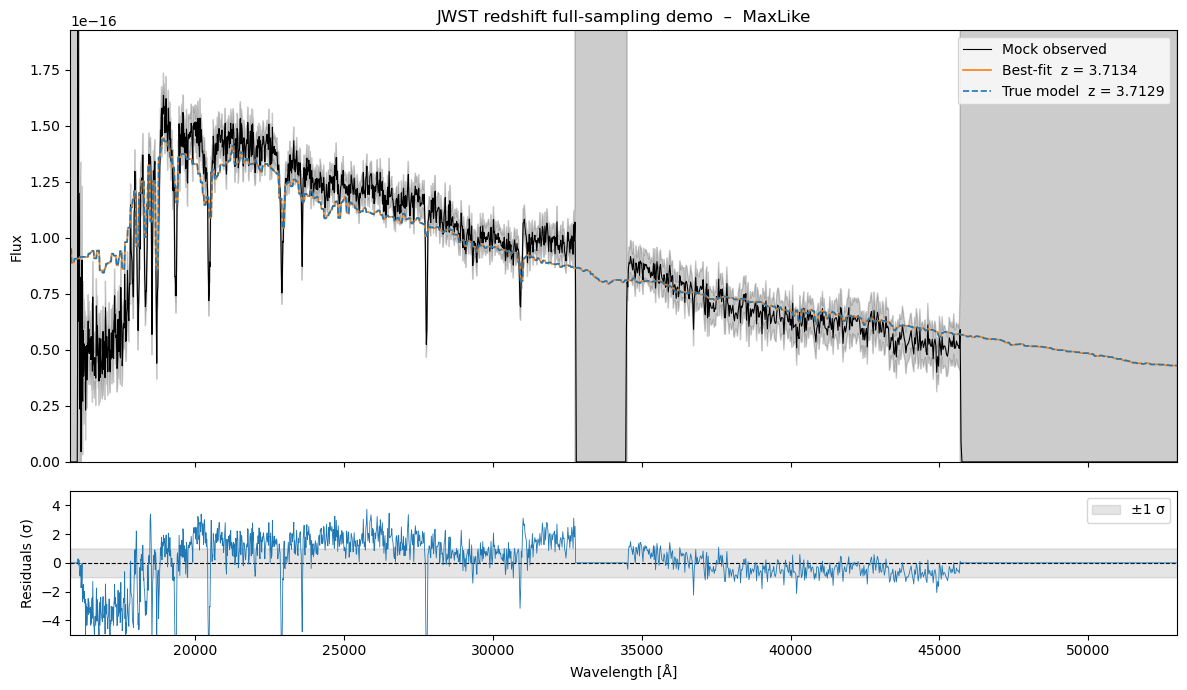

In [ ]:
# ── Plot ──────────────────────────────────────────────────────────────────────
wl = module.config["wavelength"].value   # Angstrom
obs = module.config["flux"]
err = np.sqrt(module.config["var"])
flux_model, _ = module.make_observable(solution)


plot_path = tutorial_dir / "redshift_fit_full_sampling_jwst.png"

fig, axes = plt.subplots(
    2, 1, figsize=(12, 7), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

axes[0].fill_between(wl, obs - err, obs + err, color="k", alpha=0.2)
axes[0].plot(wl, obs, color="k", lw=0.8, label="Mock observed")
axes[0].plot(
    wl, flux_model, color="C1", lw=1.2,
    label=f"Best-fit  z = {z_recovered:.4f}",
)
axes[0].set_ylabel("Flux")
axes[0].legend()
axes[0].set_title("JWST redshift full-sampling demo  –  MaxLike")
axes[0].set_xlim(wl.min(), wl.max())
axes[0].set_ylim(obs.min(), obs.max())

residuals = (obs - flux_model) / err
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[1].fill_between(wl, -1, 1, color="k", alpha=0.1, label="±1 σ")
axes[1].plot(wl, residuals, color="C0", lw=0.6)
axes[1].set_ylabel("Residuals (σ)")
axes[1].set_xlabel("Wavelength [Å]")
axes[1].set_ylim(-5, 5)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.savefig(plot_path, dpi=150)
print(f"Plot saved to {plot_path}")
plt.show()
